In [1]:
import os
import shutil
import glob
import yaml
from pathlib import Path

# Source dataset
SRC_BASE = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'
SRC_SPLITS = {
    'train': f'{SRC_BASE}/VisDrone2019-DET-train',
    'val':   f'{SRC_BASE}/VisDrone2019-DET-val',
    'test':  f'{SRC_BASE}/VisDrone2019-DET-test-dev',
}

# Output dataset (writable area)
OUT_BASE = '/kaggle/working/visdrone_processed'

# Class mapping: Original → New
# Original: 0=Pedestrian, 1=People, 3=Car
# New:      0=Human (merged Ped+People), 1=Car
ORIGINAL_TO_NEW = {
    0: 0,  # Pedestrian → Human
    1: 0,  # People → Human
    3: 1,  # Car → Car
}
NEW_CLASS_NAMES = {0: 'Human', 1: 'Car'}
TARGET_ORIGINAL_IDS = set(ORIGINAL_TO_NEW.keys())

print("✅ Preprocessing config ready")
print(f"   Mapping: Pedestrian(0)→Human(0), People(1)→Human(0), Car(3)→Car(1)")
print(f"   Output: {OUT_BASE}")


# Preprocessing — Remap Labels & Copy Images

stats = {}

for split_name, src_path in SRC_SPLITS.items():
    src_img_dir = os.path.join(src_path, 'images')
    src_lbl_dir = os.path.join(src_path, 'labels')

    out_img_dir = os.path.join(OUT_BASE, 'images', split_name)
    out_lbl_dir = os.path.join(OUT_BASE, 'labels', split_name)
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    total_images = 0
    total_kept = 0
    total_dropped = 0
    images_with_targets = 0
    empty_after_filter = 0

    lbl_files = sorted(glob.glob(os.path.join(src_lbl_dir, '*.txt')))

    for lbl_file in lbl_files:
        stem = Path(lbl_file).stem
        src_img = os.path.join(src_img_dir, f'{stem}.jpg')

        if not os.path.exists(src_img):
            continue

        total_images += 1

        # Read and remap labels
        new_lines = []
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                if cls_id in TARGET_ORIGINAL_IDS:
                    new_cls = ORIGINAL_TO_NEW[cls_id]
                    new_lines.append(f"{new_cls} {' '.join(parts[1:5])}\n")
                    total_kept += 1
                else:
                    total_dropped += 1

        # Write new label file (even if empty — keeps background images)
        out_lbl_file = os.path.join(out_lbl_dir, f'{stem}.txt')
        with open(out_lbl_file, 'w') as f:
            f.writelines(new_lines)

        if new_lines:
            images_with_targets += 1
        else:
            empty_after_filter += 1

        # Symlink image (saves disk space) — fallback to copy
        out_img = os.path.join(out_img_dir, f'{stem}.jpg')
        try:
            os.symlink(src_img, out_img)
        except (OSError, NotImplementedError):
            shutil.copy2(src_img, out_img)

    stats[split_name] = {
        'images': total_images,
        'kept': total_kept,
        'dropped': total_dropped,
        'with_targets': images_with_targets,
        'empty': empty_after_filter
    }

    print(f"\n✅ {split_name.upper()}: {total_images} images processed")
    print(f"   Annotations kept:    {total_kept:>7,}")
    print(f"   Annotations dropped: {total_dropped:>7,}")
    print(f"   Images with targets: {images_with_targets}")
    print(f"   Background images:   {empty_after_filter}")

print(f"\nOutput saved to: {OUT_BASE}")



# Preprocessing — Create data.yaml
data_yaml = {
    'path': OUT_BASE,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 2,
    'names': ['Human', 'Car']
}

yaml_path = os.path.join(OUT_BASE, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("✅ data.yaml created:")
print(f"   Path: {yaml_path}")
print(f"\n   Contents:")
with open(yaml_path, 'r') as f:
    print(f.read())


# Preprocessing — Verify Processed Dataset

for split_name in ['train', 'val', 'test']:
    img_dir = os.path.join(OUT_BASE, 'images', split_name)
    lbl_dir = os.path.join(OUT_BASE, 'labels', split_name)

    imgs = glob.glob(os.path.join(img_dir, '*.jpg'))
    lbls = glob.glob(os.path.join(lbl_dir, '*.txt'))

    # Count annotations per class
    class_counts = {0: 0, 1: 0}
    for lbl_file in lbls:
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls = int(parts[0])
                    class_counts[cls] = class_counts.get(cls, 0) + 1

    total = sum(class_counts.values())
    print(f"\n{split_name.upper()}:")
    print(f"  Images: {len(imgs)}")
    print(f"  Labels: {len(lbls)}")
    print(f"  Human (cls 0): {class_counts.get(0, 0):>7,} ({class_counts.get(0,0)/max(total,1)*100:.1f}%)")
    print(f"  Car   (cls 1): {class_counts.get(1, 0):>7,} ({class_counts.get(1,0)/max(total,1)*100:.1f}%)")
    print(f"  Total:         {total:>7,}")

    # Verify a random label file
    import random
    sample_lbl = random.choice(lbls)
    with open(sample_lbl, 'r') as f:
        content = f.read()
    print(f"\n  Sample label ({Path(sample_lbl).name}):")
    for line in content.strip().split('\n')[:5]:
        print(f"    {line}")

print("\n✅ Dataset ready for training!")


✅ Preprocessing config ready
   Mapping: Pedestrian(0)→Human(0), People(1)→Human(0), Car(3)→Car(1)
   Output: /kaggle/working/visdrone_processed

✅ TRAIN: 6471 images processed
   Annotations kept:    251,263
   Annotations dropped:  91,942
   Images with targets: 6468
   Background images:   3

✅ VAL: 548 images processed
   Annotations kept:     28,033
   Annotations dropped:  10,726
   Images with targets: 548
   Background images:   0

✅ TEST: 1610 images processed
   Annotations kept:     55,456
   Annotations dropped:  19,646
   Images with targets: 1603
   Background images:   7

Output saved to: /kaggle/working/visdrone_processed
✅ data.yaml created:
   Path: /kaggle/working/visdrone_processed/data.yaml

   Contents:
path: /kaggle/working/visdrone_processed
train: images/train
val: images/val
test: images/test
nc: 2
names:
- Human
- Car


TRAIN:
  Images: 6471
  Labels: 6471
  Human (cls 0): 106,396 (42.3%)
  Car   (cls 1): 144,867 (57.7%)
  Total:         251,263

  Sample lab

# **Train 01: Baseline: Standard resolution to establish metrics**

In [2]:
# Install Ultralytics & Setup
!pip install -q ultralytics

import torch
from ultralytics import YOLO

from IPython.display import Image, display
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.6 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


In [3]:
DATA_YAML = '/kaggle/working/visdrone_processed/data.yaml'

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB

✅ Ultralytics ready
Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone_processed/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, mult

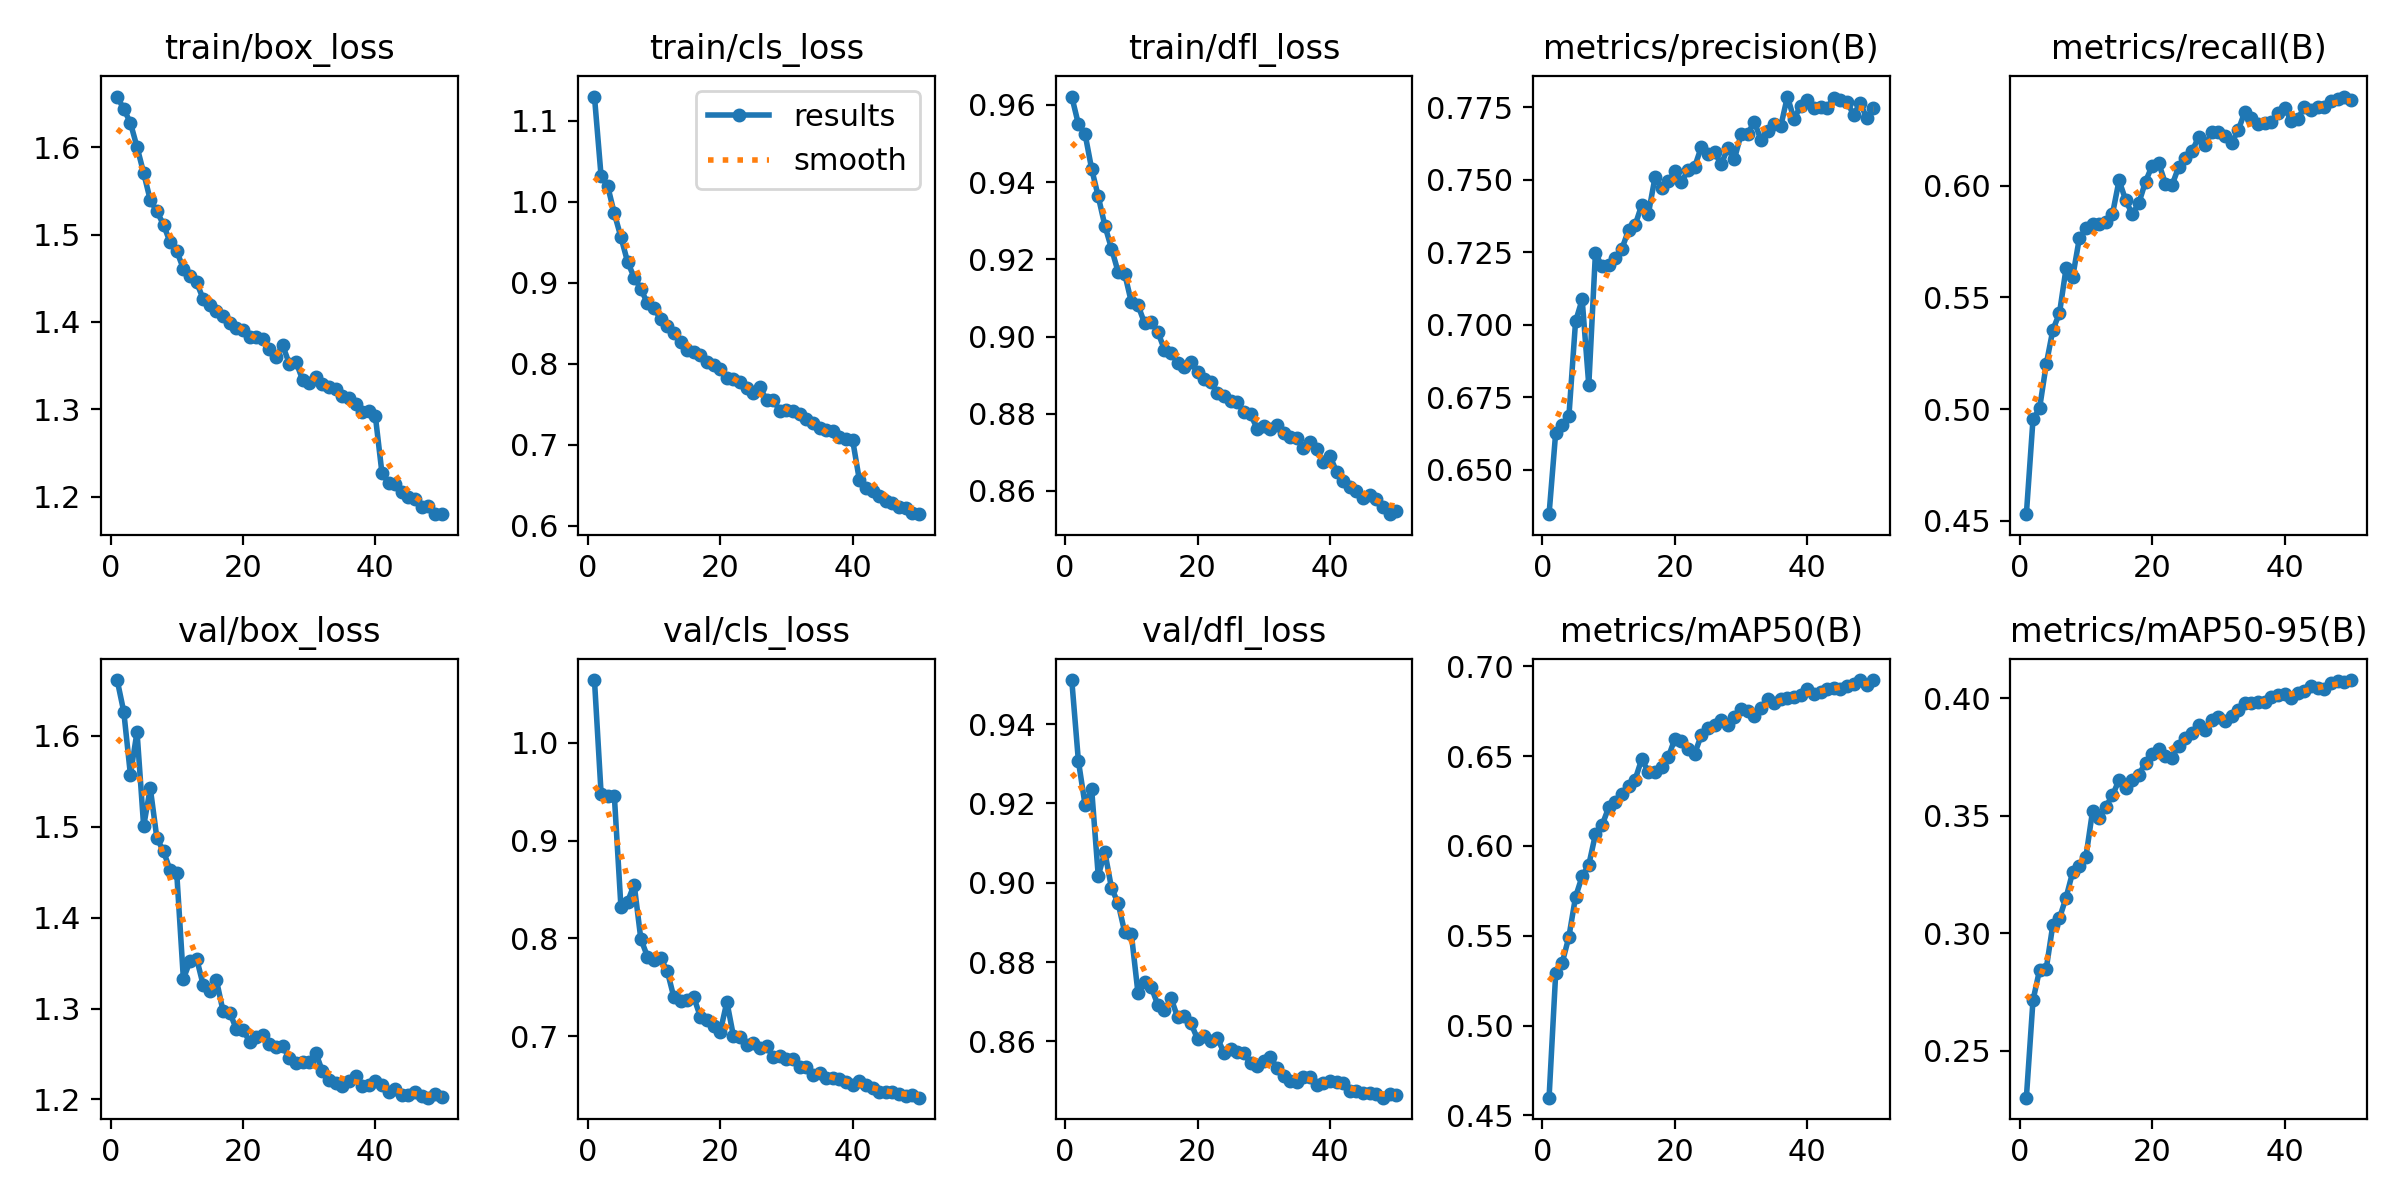


📊 confusion_matrix.png:


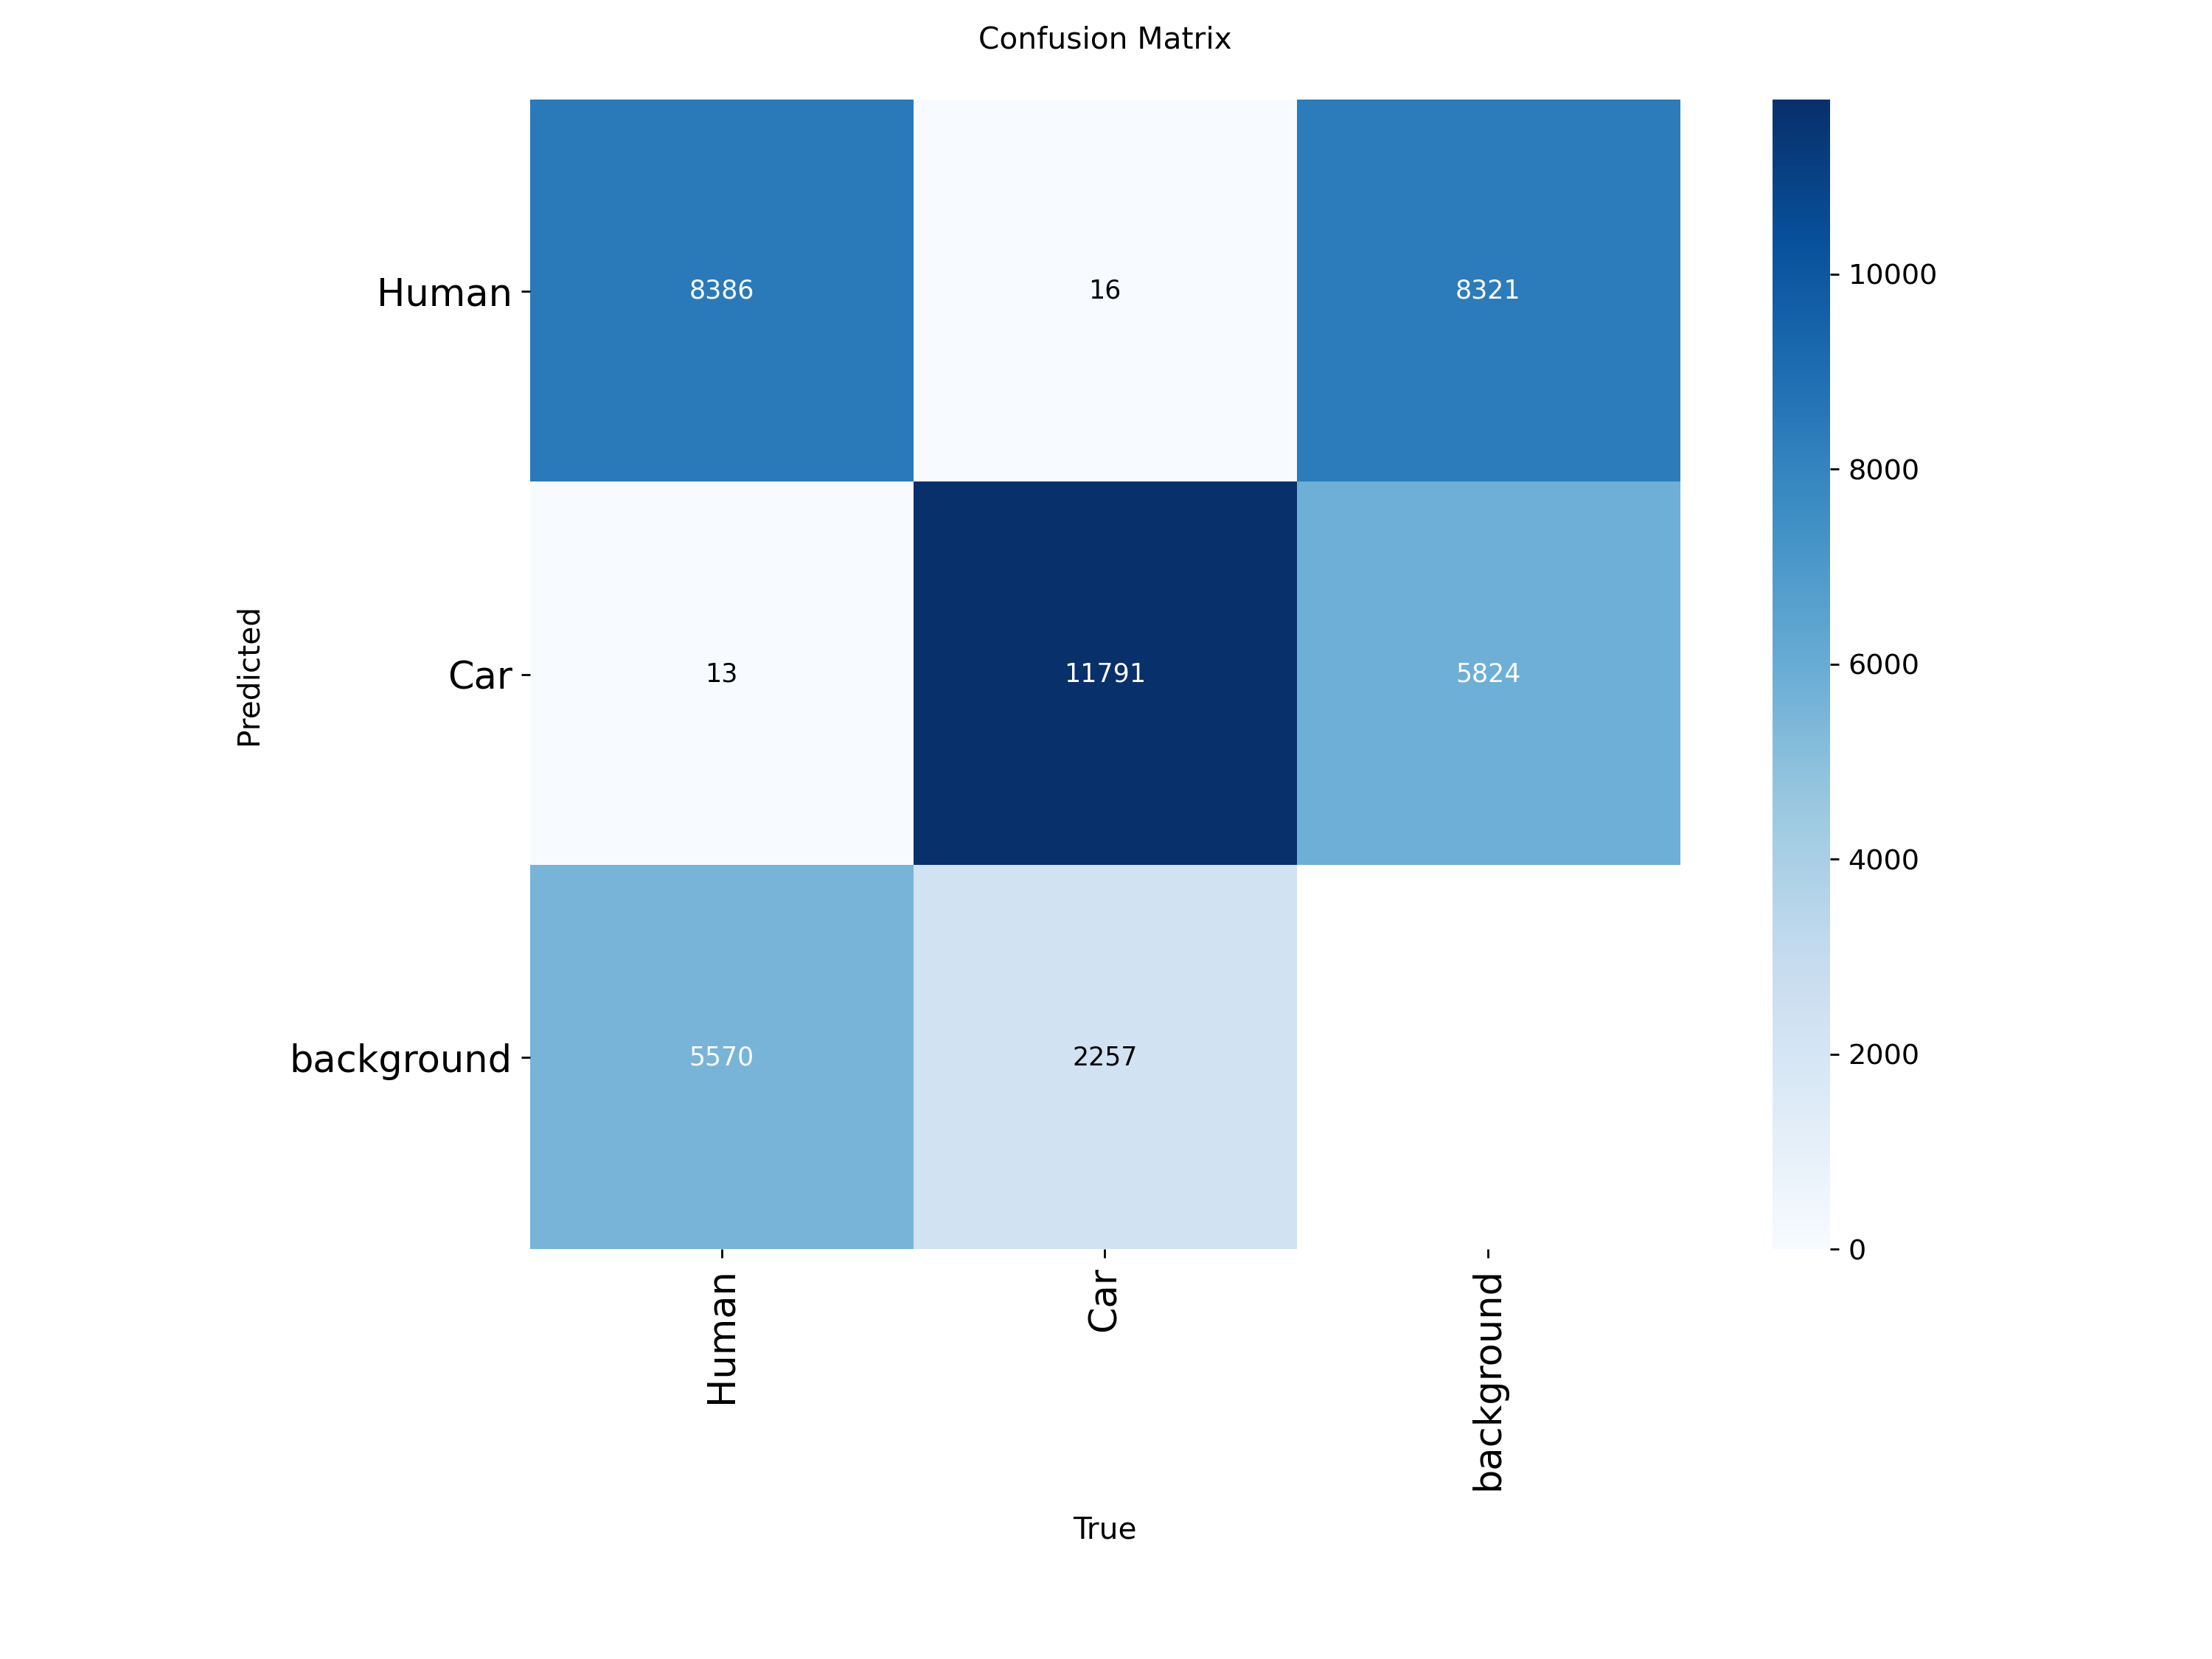


📊 confusion_matrix_normalized.png:


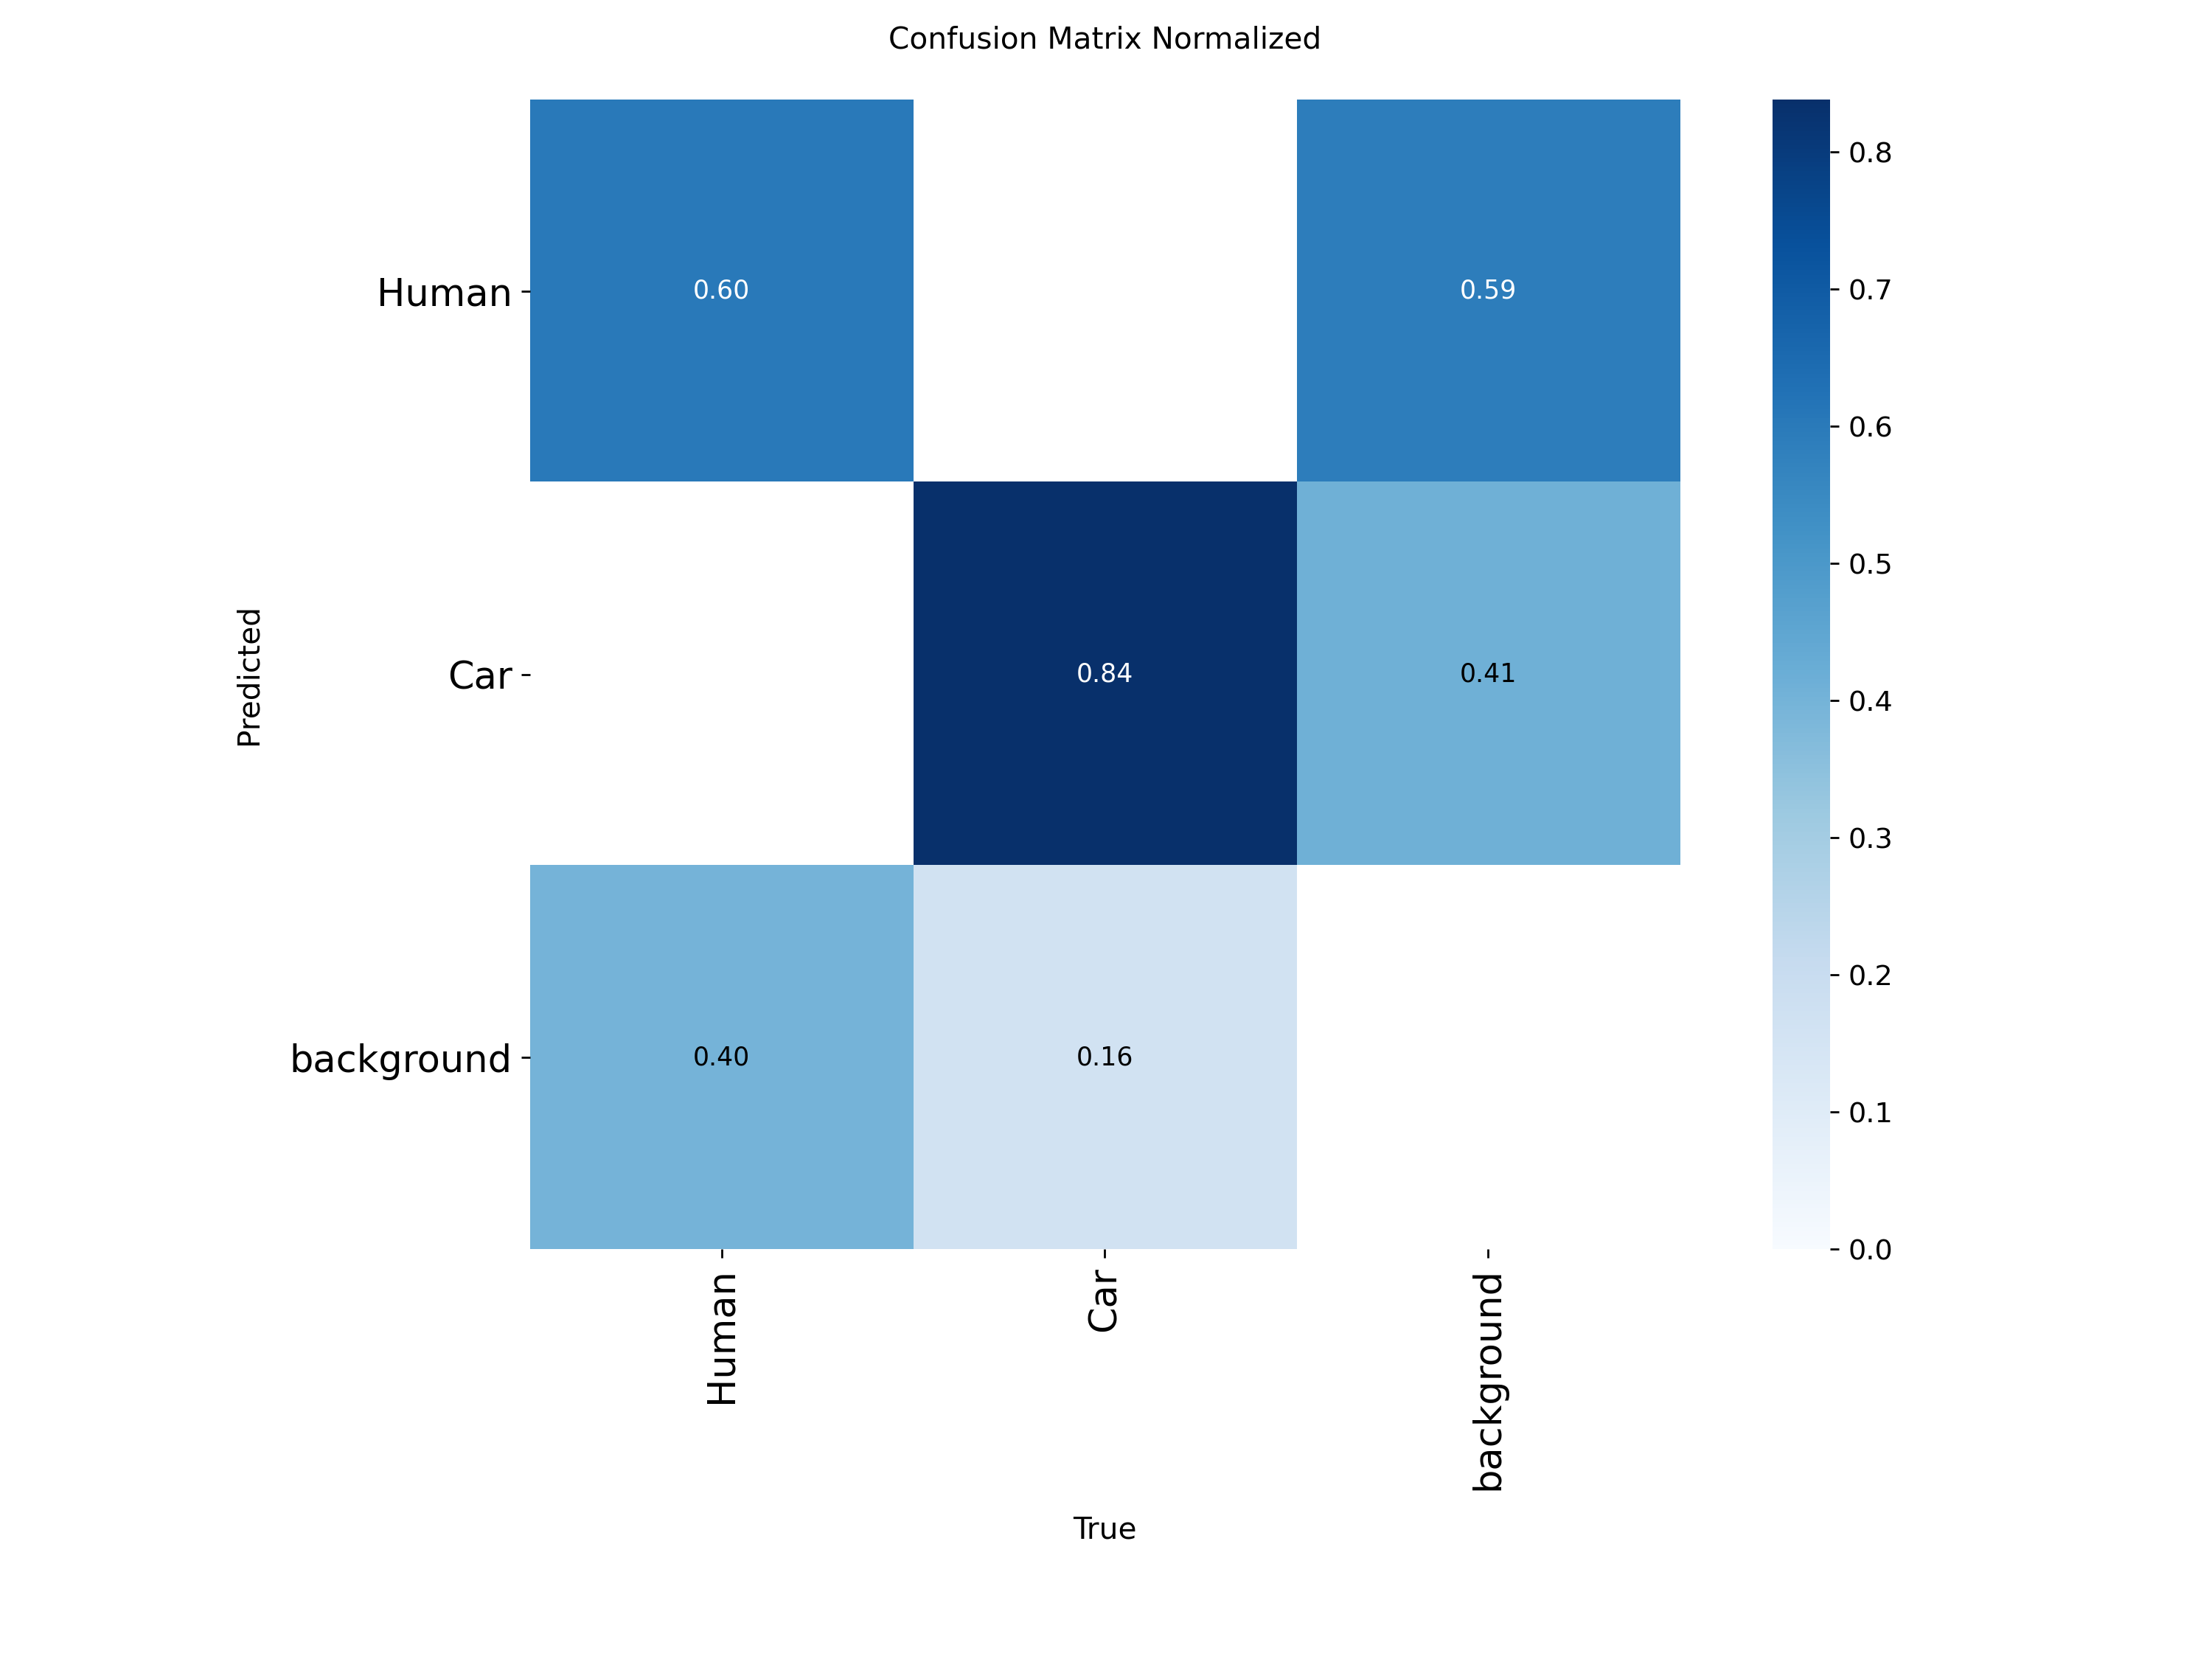


📋 BASELINE METRICS SUMMARY:
Check the results.csv for detailed epoch-by-epoch metrics

  Final Epoch: 50
  train/box_loss: 1.1801
  train/cls_loss: 0.6145
  train/dfl_loss: 0.8549
  metrics/precision(B): 0.7746
  metrics/recall(B): 0.6383
  metrics/mAP50(B): 0.6922
  metrics/mAP50-95(B): 0.4077
  val/box_loss: 1.2025
  val/cls_loss: 0.6372
  val/dfl_loss: 0.8466


In [3]:
# Training — YOLOv11m Baseline (640)

# Baseline: Standard resolution to establish metrics
model = YOLO('yolo11m.pt')  



results_baseline = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
    patience=15,           # early stopping
    augment=True,
    mosaic=1.0,            # mosaic augmentation — great for dense scenes
    mixup=0.1,             # light mixup
    scale=0.5,             # scale augmentation
    fliplr=0.5,            # horizontal flip
    hsv_h=0.015,           # hue augmentation
    hsv_s=0.7,             # saturation augmentation
    hsv_v=0.4,             # value augmentation
    degrees=5.0,           # slight rotation
    translate=0.1,
    project='/kaggle/working/runs',
    name='baseline_640',
    save=True,
    save_period=10,        # save checkpoint every 10 epochs
    plots=True,
    verbose=True,
    workers=4,
    exist_ok=True,
)

print("\n✅ Baseline training complete!")
print(f"Results saved to: /kaggle/working/runs/baseline_640/")


# Baseline Results Analysis

results_dir = '/kaggle/working/runs/baseline_640'

# Display training curves
plots = ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png',
         'P_curve.png', 'R_curve.png', 'F1_curve.png', 'PR_curve.png']

for plot in plots:
    plot_path = os.path.join(results_dir, plot)
    if os.path.exists(plot_path):
        print(f"\n📊 {plot}:")
        display(Image(filename=plot_path, width=800))

# Display sample predictions
for pred_img in ['val_batch0_pred.png', 'val_batch1_pred.png', 'val_batch2_pred.png']:
    pred_path = os.path.join(results_dir, pred_img)
    if os.path.exists(pred_path):
        print(f"\n🖼️ {pred_img}:")
        display(Image(filename=pred_path, width=800))

# Print final metrics
print("\n📋 BASELINE METRICS SUMMARY:")
print("Check the results.csv for detailed epoch-by-epoch metrics")
import pandas as pd
csv_path = os.path.join(results_dir, 'results.csv')
if os.path.exists(csv_path):
    metrics_df = pd.read_csv(csv_path)
    metrics_df.columns = metrics_df.columns.str.strip()
    last = metrics_df.iloc[-1]
    print(f"\n  Final Epoch: {len(metrics_df)}")
    for col in metrics_df.columns:
        if any(k in col.lower() for k in ['map', 'precision', 'recall', 'loss']):
            print(f"  {col}: {last[col]:.4f}")


# **Train 02: Higher resolution to tackle the small object problem**

In [7]:
model_opt = YOLO('yolo11m.pt')

results_optimized = model_opt.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=1280,            # 2x resolution — critical for small objects
    batch=4,               # reduced batch for GPU memory at 1280
    optimizer='AdamW',
    lr0=0.0005,            # slightly lower LR for stability at high res
    lrf=0.01,
    warmup_epochs=5,
    patience=20,
    augment=True,
    mosaic=1.0,
    mixup=0.15,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    project='/kaggle/working/runs',
    name='optimized_1280',
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
    workers=4,
    exist_ok=True,
)

print("\nOptimized training complete!")
print(f"Results saved to: /kaggle/working/runs/optimized_1280/")

# Result Analysis
results_dir_opt = '/kaggle/working/runs/optimized_1280'

plots = ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png',
         'P_curve.png', 'R_curve.png', 'F1_curve.png', 'PR_curve.png']

for plot in plots:
    plot_path = os.path.join(results_dir_opt, plot)
    if os.path.exists(plot_path):
        print(f"\n{plot}:")
        display(Image(filename=plot_path, width=800))

for pred_img in ['val_batch0_pred.png', 'val_batch1_pred.png', 'val_batch2_pred.png']:
    pred_path = os.path.join(results_dir_opt, pred_img)
    if os.path.exists(pred_path):
        print(f"\n{pred_img}:")
        display(Image(filename=pred_path, width=800))

# Metrics comparison
print("\nOPTIMIZED METRICS SUMMARY:")
csv_path_opt = os.path.join(results_dir_opt, 'results.csv')
if os.path.exists(csv_path_opt):
    metrics_opt = pd.read_csv(csv_path_opt)
    metrics_opt.columns = metrics_opt.columns.str.strip()
    last_opt = metrics_opt.iloc[-1]
    print(f"  Final Epoch: {len(metrics_opt)}")
    for col in metrics_opt.columns:
        if any(k in col.lower() for k in ['map', 'precision', 'recall', 'loss']):
            print(f"  {col}: {last_opt[col]:.4f}")



# Model Comparison Baseline vs Optimized
import matplotlib.pyplot as plt

print("BASELINE (640) vs OPTIMIZED (1280) COMPARISON")
print("=" * 60)

# Load both CSV results
csv_base = '/kaggle/working/runs/baseline_640/results.csv'
csv_opt = '/kaggle/working/runs/optimized_1280/results.csv'

if os.path.exists(csv_base) and os.path.exists(csv_opt):
    df_base = pd.read_csv(csv_base)
    df_opt = pd.read_csv(csv_opt)
    df_base.columns = df_base.columns.str.strip()
    df_opt.columns = df_opt.columns.str.strip()

    # Find common metric columns
    metric_cols = [c for c in df_base.columns if any(k in c.lower() for k in ['map', 'precision', 'recall'])]

    # Comparison table
    print("\nFinal Epoch Comparison:")
    print(f"{'Metric':<35} {'Baseline(640)':>15} {'Optimized(1280)':>15} {'Δ':>10}")
    print("-" * 75)
    for col in metric_cols:
        b_val = df_base[col].iloc[-1]
        o_val = df_opt[col].iloc[-1]
        delta = o_val - b_val
        arrow = "↑" if delta > 0 else "↓" if delta < 0 else "="
        print(f"{col:<35} {b_val:>15.4f} {o_val:>15.4f} {arrow}{abs(delta):>8.4f}")

    # Plot training curves side by side
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for i, metric in enumerate(['metrics/mAP50(B)', 'metrics/mAP50-95(B)',
                                  'metrics/precision(B)', 'metrics/recall(B)']):
        ax = axes[i // 2][i % 2]
        if metric in df_base.columns:
            ax.plot(df_base[metric], label='Baseline (640)', linewidth=2)
        if metric in df_opt.columns:
            ax.plot(df_opt[metric], label='Optimized (1280)', linewidth=2)
        ax.set_title(metric.replace('metrics/', ''), fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle('Baseline (640) vs Optimized (1280) — Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("One or both results CSVs not found. Run both training cells first.")


Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone_processed/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optimized_1280, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overl

KeyboardInterrupt: 

In [4]:
from ultralytics import YOLO

# Load from the last saved checkpoint
model_resume = YOLO('/kaggle/working/runs/optimized_1280/weights/last.pt')

results = model_resume.train(
    data='/kaggle/working/visdrone_processed/data.yaml',
    epochs=80,
    imgsz=1280,
    batch=4,                # can increase batch with 2 GPUs        
    optimizer='AdamW',
    lr0=0.0005,
    lrf=0.01,
    warmup_epochs=0,        # no warmup needed on resume
    patience=20,
    augment=True,
    mosaic=1.0,
    mixup=0.15,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    project='/kaggle/working/runs',
    name='optimized_1280',
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
    workers=4,
    exist_ok=True,
    resume=True,            # resume from last.pt checkpoint
)


Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone_processed/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/kaggle/working/runs/optimized_1280/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optimized_1280, nbs=64, nms=False, opset=None, 

KeyboardInterrupt: 

In [6]:
results_dir_opt = '/kaggle/working/runs/optimized_1280'

plots = ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png',
         'P_curve.png', 'R_curve.png', 'F1_curve.png', 'PR_curve.png']

for plot in plots:
    plot_path = os.path.join(results_dir_opt, plot)
    if os.path.exists(plot_path):
        print(f"\n{plot}:")
        display(Image(filename=plot_path, width=800))

for pred_img in ['val_batch0_pred.png', 'val_batch1_pred.png', 'val_batch2_pred.png']:
    pred_path = os.path.join(results_dir_opt, pred_img)
    if os.path.exists(pred_path):
        print(f"\n{pred_img}:")
        display(Image(filename=pred_path, width=800))

BASELINE (640) vs OPTIMIZED (1280) COMPARISON

Final Epoch Comparison:
Metric                                Baseline(640) Optimized(1280)          Δ
---------------------------------------------------------------------------
metrics/precision(B)                         0.7746          0.8337 ↑  0.0591
metrics/recall(B)                            0.6383          0.7708 ↑  0.1325
metrics/mAP50(B)                             0.6922          0.8265 ↑  0.1344
metrics/mAP50-95(B)                          0.4077          0.5136 ↑  0.1060


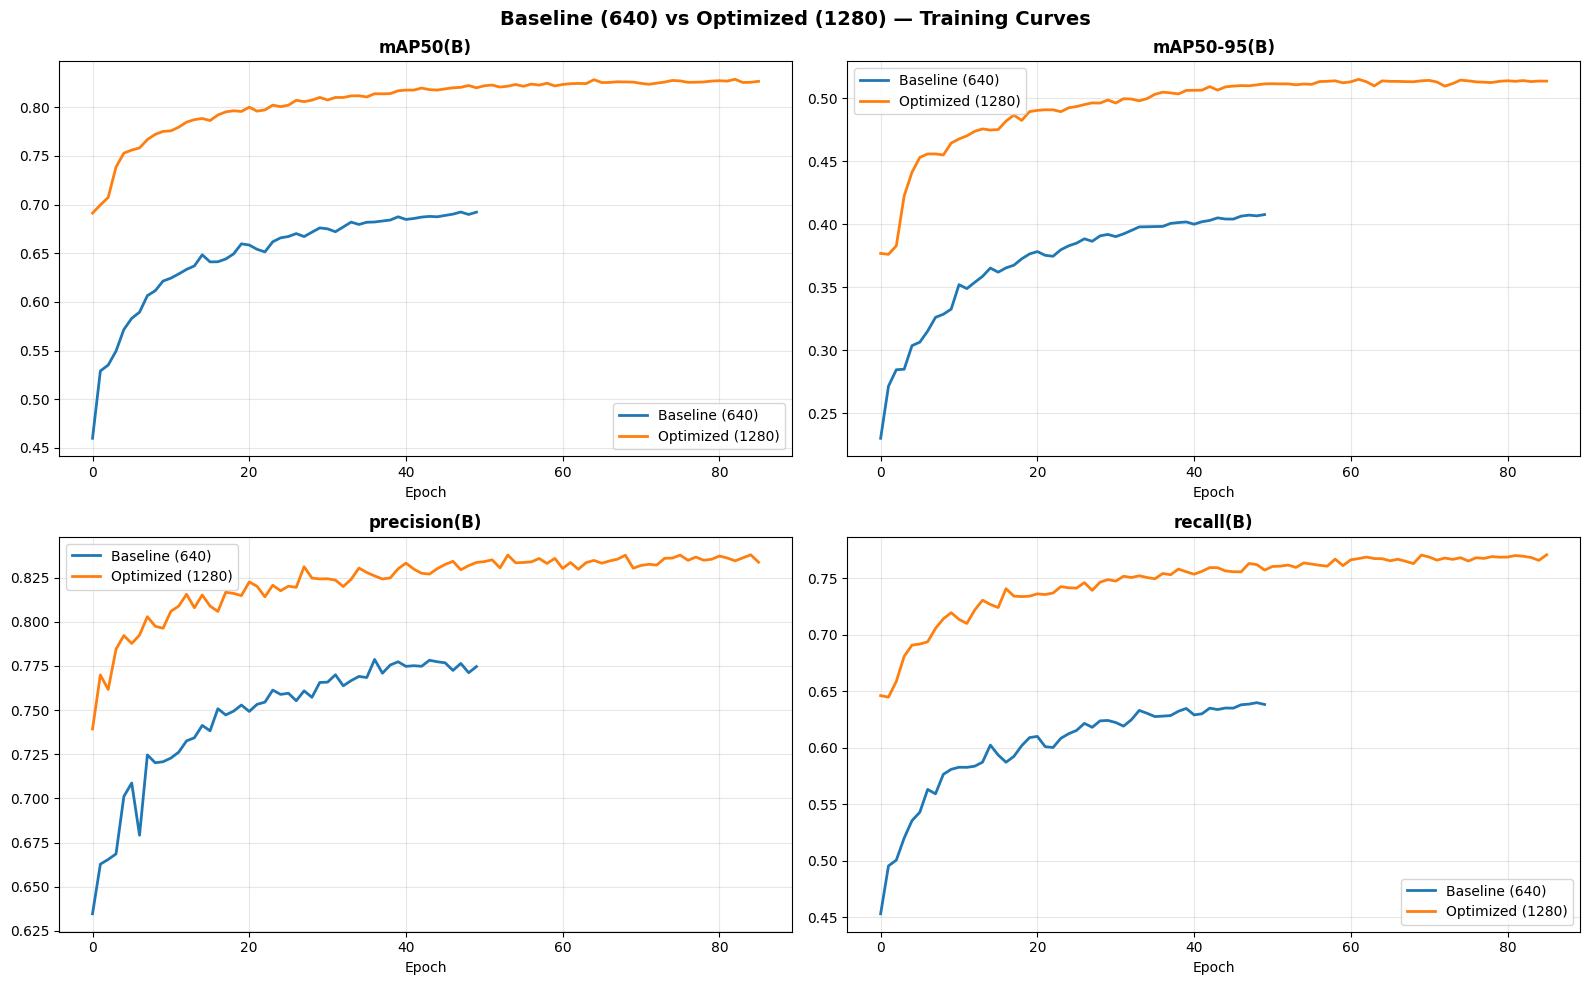

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

print("BASELINE (640) vs OPTIMIZED (1280) COMPARISON")
print("=" * 60)

# Load both CSV results
csv_base = '/kaggle/working/runs/baseline_640/results.csv'
csv_opt = '/kaggle/working/runs/optimized_1280/results.csv'

if os.path.exists(csv_base) and os.path.exists(csv_opt):
    df_base = pd.read_csv(csv_base)
    df_opt = pd.read_csv(csv_opt)
    df_base.columns = df_base.columns.str.strip()
    df_opt.columns = df_opt.columns.str.strip()

    # Find common metric columns
    metric_cols = [c for c in df_base.columns if any(k in c.lower() for k in ['map', 'precision', 'recall'])]

    # Comparison table
    print("\nFinal Epoch Comparison:")
    print(f"{'Metric':<35} {'Baseline(640)':>15} {'Optimized(1280)':>15} {'Δ':>10}")
    print("-" * 75)
    for col in metric_cols:
        b_val = df_base[col].iloc[-1]
        o_val = df_opt[col].iloc[-1]
        delta = o_val - b_val
        arrow = "↑" if delta > 0 else "↓" if delta < 0 else "="
        print(f"{col:<35} {b_val:>15.4f} {o_val:>15.4f} {arrow}{abs(delta):>8.4f}")

    # Plot training curves side by side
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for i, metric in enumerate(['metrics/mAP50(B)', 'metrics/mAP50-95(B)',
                                  'metrics/precision(B)', 'metrics/recall(B)']):
        ax = axes[i // 2][i % 2]
        if metric in df_base.columns:
            ax.plot(df_base[metric], label='Baseline (640)', linewidth=2)
        if metric in df_opt.columns:
            ax.plot(df_opt[metric], label='Optimized (1280)', linewidth=2)
        ax.set_title(metric.replace('metrics/', ''), fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle('Baseline (640) vs Optimized (1280) — Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("One or both results CSVs not found. Run both training cells first.")
